In [2]:

!pip install yfinance pandas numpy matplotlib seaborn scikit-learn statsmodels


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [4]:
# AAPL - Apple Inc.
stock_ticker = 'AAPL'
stock_data = yf.download(stock_ticker, start="2010-01-01", end="2024-01-01")

stock_data.to_csv("stock_data.csv")

stock_data = pd.read_csv("stock_data.csv", index_col=0, parse_dates=True)


if "Adj Close" in stock_data.columns:
    stock_data["Close"] = stock_data["Adj Close"]

# Display dataset info
print(stock_data.info())

# Show first few rows
print(stock_data.head())


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
<ipython-input-4-509aec546ce4>:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stock_data = pd.read_csv("stock_data.csv", index_col=0, parse_dates=True)


<class 'pandas.core.frame.DataFrame'>
Index: 3524 entries, Ticker to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Close   3523 non-null   object
 1   High    3523 non-null   object
 2   Low     3523 non-null   object
 3   Open    3523 non-null   object
 4   Volume  3523 non-null   object
dtypes: object(5)
memory usage: 165.2+ KB
None
                        Close               High                Low  \
Price                                                                 
Ticker                   AAPL               AAPL               AAPL   
Date                      NaN                NaN                NaN   
2010-01-04  6.440329551696777  6.455075347440217  6.391277079556666   
2010-01-05  6.451466083526611  6.487879368872802  6.417459939457402   
2010-01-06  6.348846912384033  6.477045767122851  6.342226169002906   

                         Open     Volume  
Price                                     
Ticke

In [5]:
# Check for missing values
missing_values = stock_data.isnull().sum()
print("Missing values in each column:\n", missing_values)


Missing values in each column:
 Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


0 NaT values in index


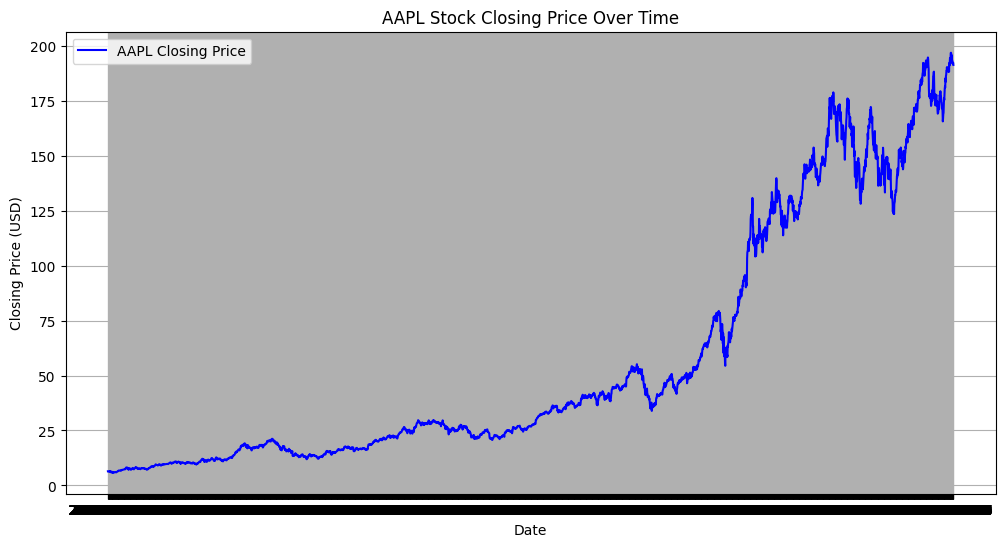

In [6]:
cols = ["Close", "High", "Low", "Open", "Volume"]
stock_data[cols] = stock_data[cols].apply(pd.to_numeric, errors='coerce')

# Drop NaN values (if any)
stock_data.dropna(inplace=True)

# Ensure index is in datetime format and check for NaT values
print(stock_data.index.isna().sum(), "NaT values in index")


# Plot Closing Price Over Time
plt.figure(figsize=(12,6))
plt.plot(stock_data["Close"], label=f"{stock_ticker} Closing Price", color="blue")
plt.title(f"{stock_ticker} Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid()
plt.show()

50_MA      49
200_MA    199
dtype: int64


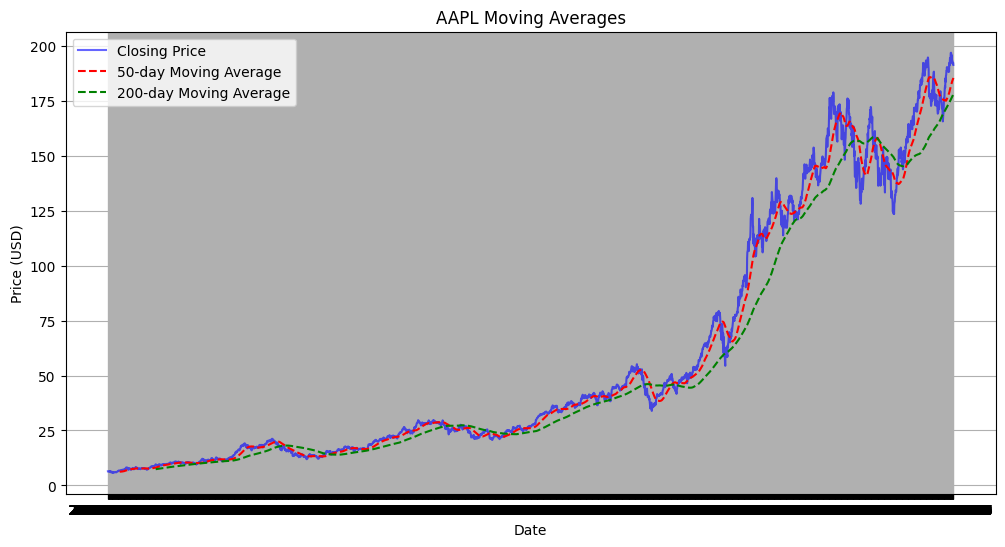

In [7]:
stock_data["50_MA"] = stock_data["Close"].rolling(window=50).mean()
stock_data["200_MA"] = stock_data["Close"].rolling(window=200).mean()

# Check for NaN values in moving averages
print(stock_data[["50_MA", "200_MA"]].isna().sum())

# Plot Moving Averages
plt.figure(figsize=(12,6))
plt.plot(stock_data["Close"], label="Closing Price", color="blue", alpha=0.6)
plt.plot(stock_data["50_MA"], label="50-day Moving Average", color="red", linestyle="dashed")
plt.plot(stock_data["200_MA"], label="200-day Moving Average", color="green", linestyle="dashed")
plt.title(f"{stock_ticker} Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid()
plt.show()

In [8]:
def compute_rsi(data, window=14):
    delta = data['Close'].diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

stock_data['RSI'] = compute_rsi(stock_data)

In [9]:
# MACD (Moving Average Convergence Divergence)
stock_data['EMA_12'] = stock_data['Close'].ewm(span=12, adjust=False).mean()
stock_data['EMA_26'] = stock_data['Close'].ewm(span=26, adjust=False).mean()
stock_data['MACD'] = stock_data['EMA_12'] - stock_data['EMA_26']
stock_data['MACD_Signal'] = stock_data['MACD'].ewm(span=9, adjust=False).mean()
# Bollinger Bands
stock_data['20_MA'] = stock_data['Close'].rolling(window=20).mean()
stock_data['20_SD'] = stock_data['Close'].rolling(window=20).std()
stock_data['Upper_Band'] = stock_data['20_MA'] + (2 * stock_data['20_SD'])
stock_data['Lower_Band'] = stock_data['20_MA'] - (2 * stock_data['20_SD'])

# Volatility & Returns
stock_data['Daily_Return'] = stock_data['Close'].pct_change()
stock_data['Log_Return'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))
stock_data['Volatility'] = stock_data['Daily_Return'].rolling(window=21).std()

# Rate of Change (ROC)
stock_data['ROC'] = stock_data['Close'].pct_change(periods=10) * 100

# Lag Features
for lag in range(1, 6):
    stock_data[f'Lag_{lag}'] = stock_data['Close'].shift(lag)

# Drop NaN values
stock_data.dropna(inplace=True)

# Save enhanced dataset
stock_data.to_csv("enhanced_stock_data.csv")

print("Feature Engineering Completed!")



Feature Engineering Completed!


Training Data: (2658, 25)
Testing Data: (665, 25)


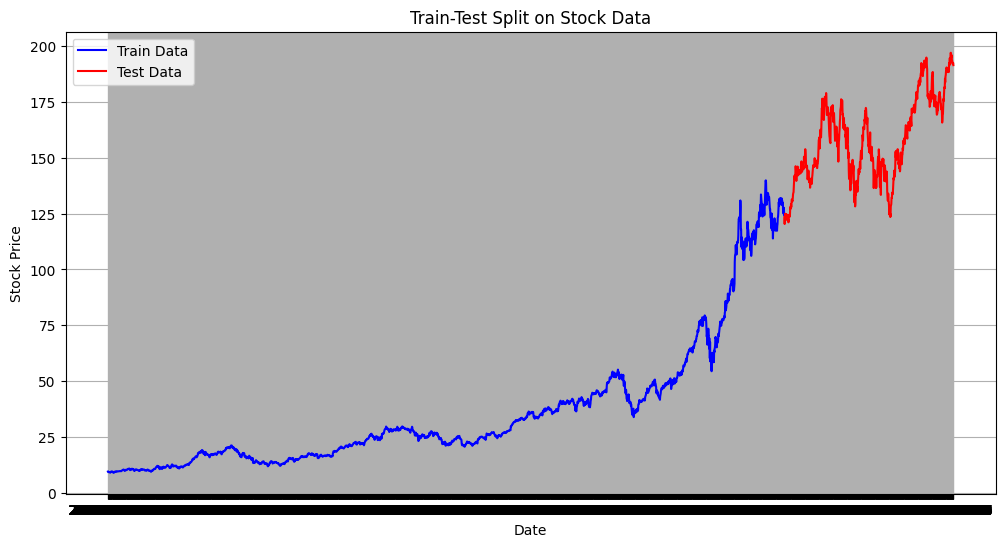

In [10]:
# Splitting into train (80%) and test (20%) while preserving order
train_size = int(len(stock_data) * 0.8)
train, test = stock_data.iloc[:train_size], stock_data.iloc[train_size:]

print(f"Training Data: {train.shape}")
print(f"Testing Data: {test.shape}")

# Plot the split
plt.figure(figsize=(12,6))
plt.plot(train["Close"], label="Train Data", color="blue")
plt.plot(test["Close"], label="Test Data", color="red")
plt.title("Train-Test Split on Stock Data")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid()
plt.show()


=== ADF Test on Original Data ===
ADF Statistic: 0.8390995338955047
p-value: 0.9922417973674209
Critical Values: {'1%': np.float64(-3.432330746908277), '5%': np.float64(-2.862415177101958), '10%': np.float64(-2.5672358747522996)}
❌ The data is NOT stationary (Fail to Reject Null Hypothesis)

=== ADF Test After First-Order Differencing ===
ADF Statistic: -13.214109252774476
p-value: 1.032807666475832e-24
Critical Values: {'1%': np.float64(-3.432330746908277), '5%': np.float64(-2.862415177101958), '10%': np.float64(-2.5672358747522996)}
✅ The data is stationary (Reject Null Hypothesis)


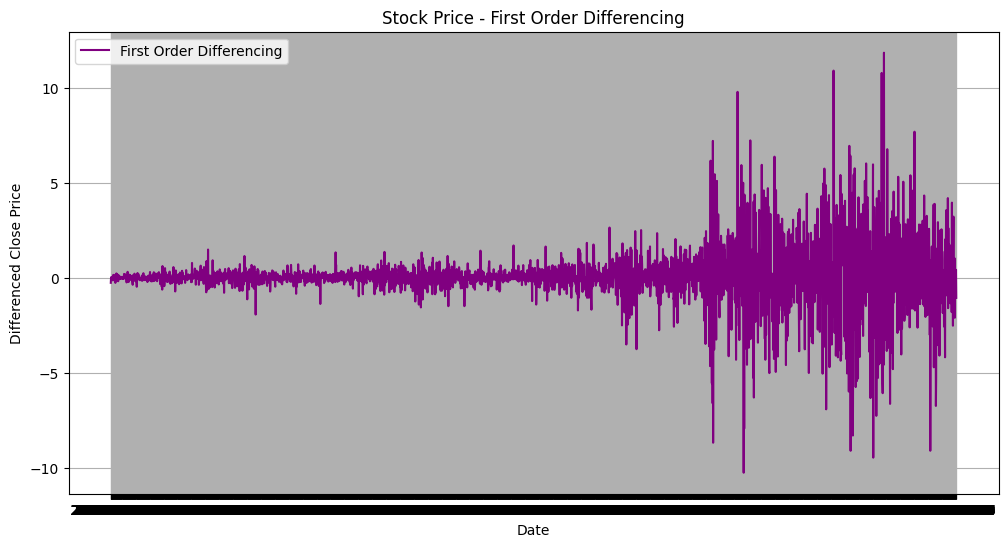

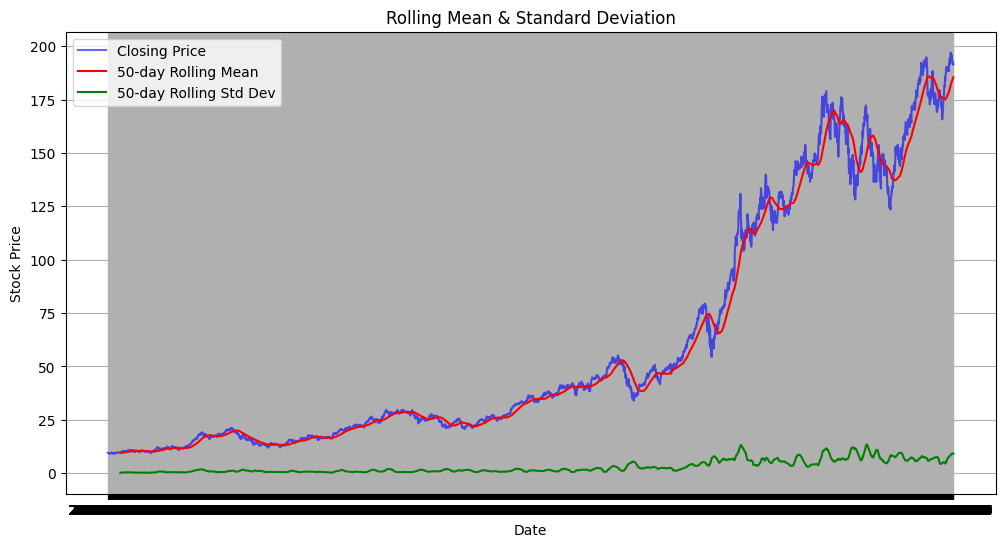

In [11]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF Test
def adf_test(series):
    result = adfuller(series.dropna())  # Drop NaN values before testing
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])

    if result[1] < 0.05:
        print("✅ The data is stationary (Reject Null Hypothesis)")
    else:
        print("❌ The data is NOT stationary (Fail to Reject Null Hypothesis)")

# Load your stock data (Ensure you have a 'Close' column in stock_data)
# stock_data = pd.read_csv("your_stock_data.csv", parse_dates=["Date"], index_col="Date")

# Perform ADF Test on the original data
print("=== ADF Test on Original Data ===")
adf_test(stock_data["Close"])

# Apply First-Order Differencing
stock_data["Close_Diff"] = stock_data["Close"].diff()

# Perform ADF Test Again on Differenced Data
print("\n=== ADF Test After First-Order Differencing ===")
adf_test(stock_data["Close_Diff"])

# Plot Differenced Data
plt.figure(figsize=(12,6))
plt.plot(stock_data["Close_Diff"], label="First Order Differencing", color="purple")
plt.title("Stock Price - First Order Differencing")
plt.xlabel("Date")
plt.ylabel("Differenced Close Price")
plt.legend()
plt.grid()
plt.show()

# Plot Rolling Mean & Standard Deviation
plt.figure(figsize=(12,6))
plt.plot(stock_data["Close"], label="Closing Price", color="blue", alpha=0.6)
plt.plot(stock_data["Close"].rolling(window=50).mean(), label="50-day Rolling Mean", color="red")
plt.plot(stock_data["Close"].rolling(window=50).std(), label="50-day Rolling Std Dev", color="green")
plt.title("Rolling Mean & Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()
plt.grid()
plt.show()

**ACF and PACF**

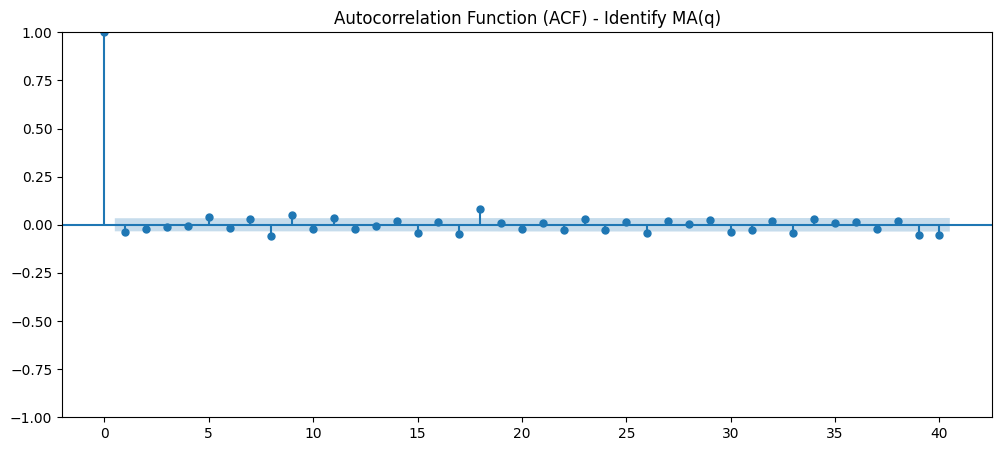

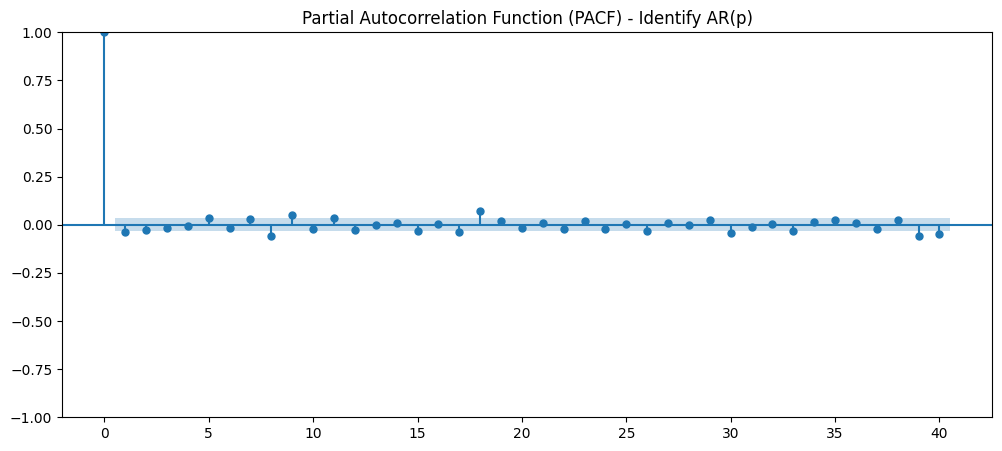

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF
plt.figure(figsize=(12,5))
plot_acf(stock_data["Close_Diff"].dropna(), lags=40, ax=plt.gca())  # Drop NaN values
plt.title("Autocorrelation Function (ACF) - Identify MA(q)")
plt.show()

# Plot PACF
plt.figure(figsize=(12,5))
plot_pacf(stock_data["Close_Diff"].dropna(), lags=40, ax=plt.gca())  # Drop NaN values
plt.title("Partial Autocorrelation Function (PACF) - Identify AR(p)")
plt.show()


In [13]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")  # Ignore warnings for cleaner output

# Define the candidate models
orders = [(1,1,0), (0,1,1), (1,1,1)]

for order in orders:
    model = ARIMA(stock_data["Close"], order=order)
    model_fit = model.fit()
    print(f"ARIMA{order} - AIC: {model_fit.aic}, BIC: {model_fit.bic}")


ARIMA(1, 1, 0) - AIC: 12046.82830126238, BIC: 12059.044945842727
ARIMA(0, 1, 1) - AIC: 12046.621842793877, BIC: 12058.838487374223
ARIMA(1, 1, 1) - AIC: 12046.980120549233, BIC: 12065.305087419752


In [14]:
# Fit the selected ARIMA(0,1,1) model
best_model = ARIMA(stock_data["Close"], order=(0,1,1))
best_model_fit = best_model.fit()

# Print model summary
print(best_model_fit.summary())




                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 3323
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -6021.311
Date:                Mon, 14 Apr 2025   AIC                          12046.622
Time:                        07:27:41   BIC                          12058.838
Sample:                             0   HQIC                         12050.993
                               - 3323                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0373      0.009     -4.305      0.000      -0.054      -0.020
sigma2         2.1973      0.022     99.653      0.000       2.154       2.241
Ljung-Box (L1) (Q):                   0.00   Jarque-

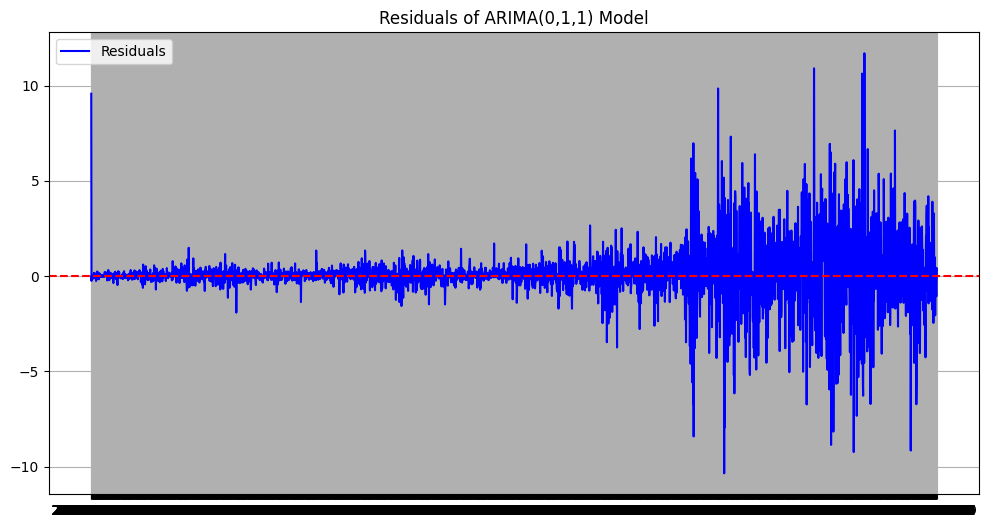

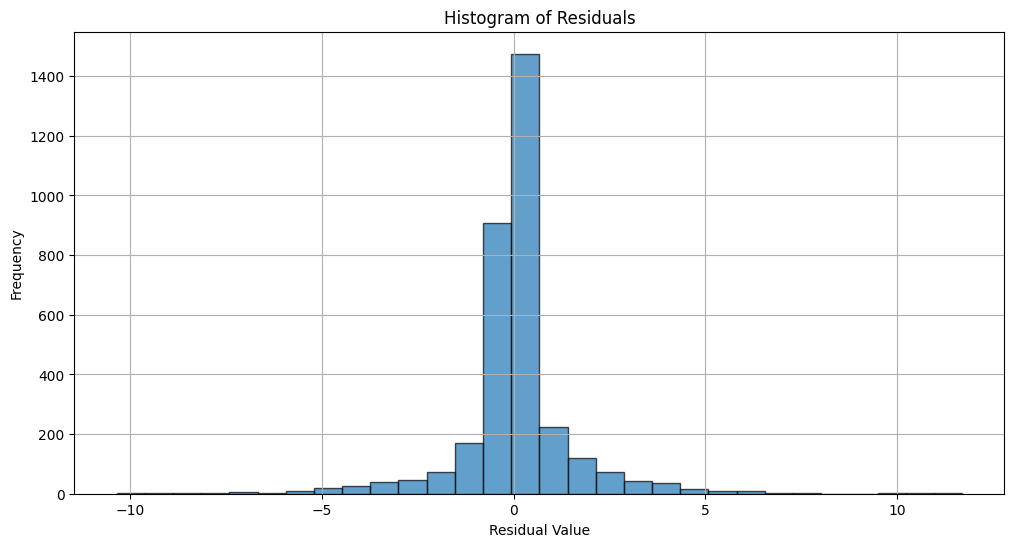

NameError: name 'sm' is not defined

In [15]:
# Plot residuals to check if they follow a normal distribution
residuals = best_model_fit.resid
plt.figure(figsize=(12,6))
plt.plot(residuals, label="Residuals", color="blue")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residuals of ARIMA(0,1,1) Model")
plt.legend()
plt.grid()
plt.show()

# Histogram of residuals
plt.figure(figsize=(12,6))
plt.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
plt.title("Histogram of Residuals")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.grid()
plt.show()

# Q-Q Plot (Checking for normality)
sm.qqplot(best_model_fit.resid, line='s', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.grid()
plt.show()

               Close      High       Low      Open        Volume     50_MA  \
Price                                                                        
2010-10-19  9.313667  9.442468  9.028681  9.130398  1.232784e+09  8.167908   
2010-10-20  9.344961  9.456909  9.234819  9.298918  7.216244e+08  8.198676   
2010-10-21  9.314571  9.471660  9.232717  9.400037  5.514600e+08  8.234385   
2010-10-22  9.252882  9.330222  9.217673  9.301031  3.727780e+08  8.267897   
2010-10-25  9.294106  9.377163  9.282068  9.301630  3.924620e+08  8.303853   

              200_MA        RSI    EMA_12    EMA_26  ...  Daily_Return  \
Price                                                ...                 
2010-10-19  7.401790  69.540565  9.057632  8.735165  ...     -0.026761   
2010-10-20  7.416257  74.787035  9.101836  8.780335  ...      0.003360   
2010-10-21  7.431086  75.093068  9.134565  8.819908  ...     -0.003252   
2010-10-22  7.445665  77.737376  9.152767  8.851981  ...     -0.006623   
2010-10-2

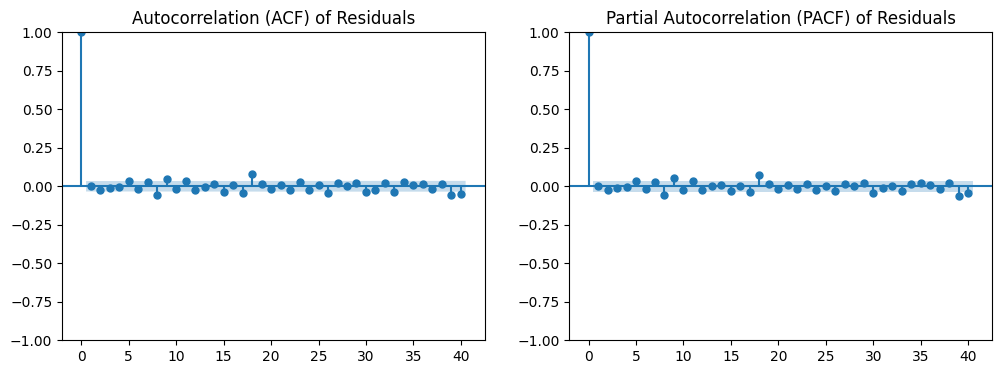

      lb_stat  lb_pvalue
10  30.570709   0.000691


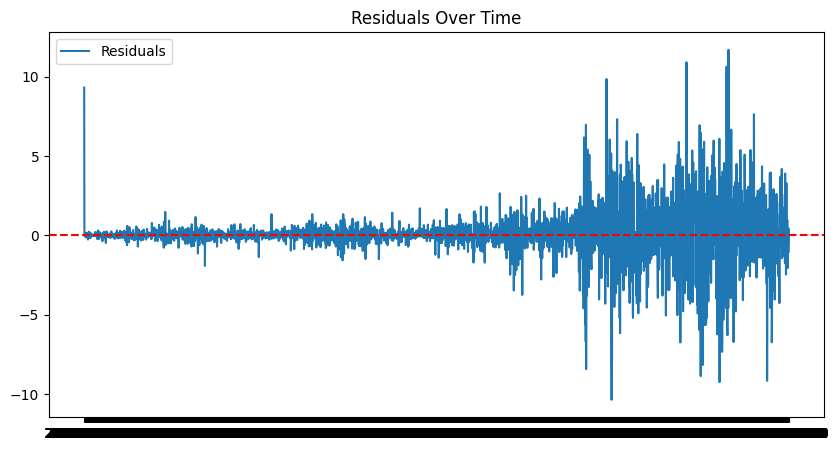

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3442.94
Distribution:                  Normal   AIC:                           6893.88
Method:            Maximum Likelihood   BIC:                           6918.31
                                        No. Observations:                 3322
Date:                Mon, Apr 14 2025   Df Residuals:                     3321
Time:                        07:31:09   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0333  7.698e-03      4.326  1.520e-05 [1.

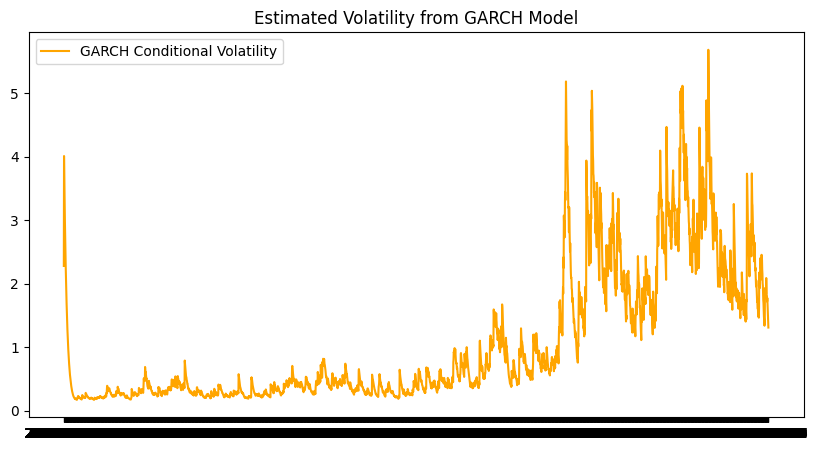

In [18]:
!pip install arch

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm


# Ensure data is loaded and clean
print(stock_data.head())  # Check if 'Close' column exists
stock_data = stock_data.dropna()

# Fit ARIMA model
best_model = ARIMA(stock_data["Close"], order=(0,1,1))
best_model_fit = best_model.fit()

# ✅ FIX: Extract residuals correctly
residuals = best_model_fit.resid

# 1. Plot ACF and PACF of residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals, ax=axes[0], lags=40)
plot_pacf(residuals, ax=axes[1], lags=40)
axes[0].set_title("Autocorrelation (ACF) of Residuals")
axes[1].set_title("Partial Autocorrelation (PACF) of Residuals")
plt.show()

# 2. Perform the Ljung-Box test
lb_test = sm.stats.acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

# 3. Check Residual Heteroskedasticity (Volatility Clustering)
plt.figure(figsize=(10, 5))
plt.plot(residuals, label="Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals Over Time")
plt.legend()
plt.show()

# 4. Apply GARCH Model if Residuals Show Volatility Clustering
garch_model = arch_model(residuals, vol="Garch", p=1, q=1)
garch_fit = garch_model.fit(disp="off")
print(garch_fit.summary())

# 5. Plot GARCH Model's Conditional Volatility
plt.figure(figsize=(10, 5))
plt.plot(garch_fit.conditional_volatility, label="GARCH Conditional Volatility", color='orange')
plt.title("Estimated Volatility from GARCH Model")
plt.legend()
plt.show()
